# =====================================================
# SECOM 반도체 공정 불량 예측 프로젝트
# UCI SECOM Dataset: 1567개 공정 기록, 591개 센서 변수
# 목표: 공정 데이터 기반 불량품(class=-1) 사전 탐지
# =====================================================

In [1]:
# ── 셀 1: 데이터 로드 ──────────────────────────────
# UCI ML Repository에서 SECOM 데이터셋(id=179) 직접 다운로드
# secom.data.original: 센서 변수 + class(양품1/불량-1) + timestamp 포함
from ucimlrepo import fetch_ucirepo
secom = fetch_ucirepo(id=179)
df = secom.data.original
df.head()

,class,timestamp,Attribute 1,Attribute 2,Attribute 3,Attribute 4,Attribute 5,Attribute 6,Attribute 7,Attribute 8,...,Attribute 581,Attribute 582,Attribute 583,Attribute 584,Attribute 585,Attribute 586,Attribute 587,Attribute 588,Attribute 589,Attribute 590
0,-1,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [2]:
# ── 셀 2: 기본 현황 파악 ───────────────────────────
# 전체 shape, 결측치 수, 클래스 분포 확인
# → 양품 1463개 / 불량 104개: 심각한 클래스 불균형 존재
print(df.shape)
df.isnull().sum().sum()
df['class'].value_counts()

(1567, 592)


class
-1    1463
 1     104
Name: count, dtype: int64

In [3]:
# ── 셀 3: 결측치 비율 확인 ─────────────────────────
# 각 컬럼의 결측치 비율(%) 계산 후 상위 20개 출력
# → 결측치 50% 이상인 컬럼은 데이터 신뢰성이 낮아 제거 대상
missing = df.isnull().sum() / len(df) * 100
missing[missing > 0].sort_values(ascending=False).head(20)

Attribute 293    91.193363
Attribute 294    91.193363
Attribute 158    91.193363
Attribute 159    91.193363
Attribute 359    85.577537
Attribute 86     85.577537
Attribute 493    85.577537
Attribute 221    85.577537
Attribute 519    64.964901
Attribute 247    64.964901
Attribute 246    64.964901
Attribute 517    64.964901
Attribute 518    64.964901
Attribute 111    64.964901
Attribute 385    64.964901
Attribute 383    64.964901
Attribute 384    64.964901
Attribute 110    64.964901
Attribute 245    64.964901
Attribute 112    64.964901
dtype: float64

In [4]:
# ── 셀 4 ~ 6: 결측치 처리 ──────────────────────────────
# 1단계: 결측치 50% 초과 컬럼 제거 (591 → 562개)
#         thresh=len(df)*0.5 → 전체 행의 50% 이상 값이 있는 컬럼만 유지
# 2단계: 나머지 결측치는 각 컬럼 평균값으로 대체
df_clean = df.dropna(thresh=len(df)*0.5, axis=1)
print(df_clean.shape)

(1567, 564)


In [5]:
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

In [6]:
df_clean.isnull().sum().sum()  # 0이면 결측치 완전 제거 확인

np.int64(0)

In [7]:
# ── 셀 7: 피처/타겟 분리 ───────────────────────────
# 입력(X): 센서 변수만 사용 (class, timestamp 제외)
# 타겟(y): class 컬럼 (양품=1, 불량=-1)
X = df_clean.drop(columns=['class', 'timestamp'])
y = df_clean['class']

print(X.shape)
print(y.value_counts())

(1567, 562)
class
-1    1463
 1     104
Name: count, dtype: int64


In [8]:
# ── 셀 8: 라이브러리 임포트 ────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [9]:
# ── 셀 9: 기본 모델 (class_weight='balanced') ──────
# 불균형 대응 1안: class_weight='balanced'로 불량 클래스에 가중치 부여
# → 모델이 소수 클래스(불량)를 더 중요하게 학습
# test_size=0.2: 전체의 20%를 테스트셋으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
# ── 셀 10: SMOTE 적용 모델 ──────────────────────────
# 불균형 대응 2안: SMOTE로 학습 데이터 내 불량 샘플 오버샘플링
# SMOTE: 기존 불량 샘플 간 보간으로 합성 샘플 생성 (train set에만 적용)
# → test set에 적용하면 데이터 누수 발생하므로 반드시 train만 사용
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_resampled, y_resampled)

y_pred2 = model2.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
# ── 셀 11: 최종 파이프라인 통합 ─────────────────────
# 위 과정을 하나의 셀로 정리한 실행용 코드
# 데이터 로드 → 전처리 → SMOTE → 모델 학습 → 평가까지 일괄 실행
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

secom = fetch_ucirepo(id=179)
df = secom.data.original

df_clean = df.dropna(thresh=len(df)*0.5, axis=1)
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

X = df_clean.drop(columns=['class', 'timestamp'])
y = df_clean['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_resampled, y_resampled)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
# ── 셀 12: SMOTE 결과 확인 ─────────────────────────
# 오버샘플링 후 클래스 분포 확인
# → 양품/불량이 동수가 됐는지 검증
print(y_resampled.value_counts())

class
-1    1173
 1    1173
Name: count, dtype: int64


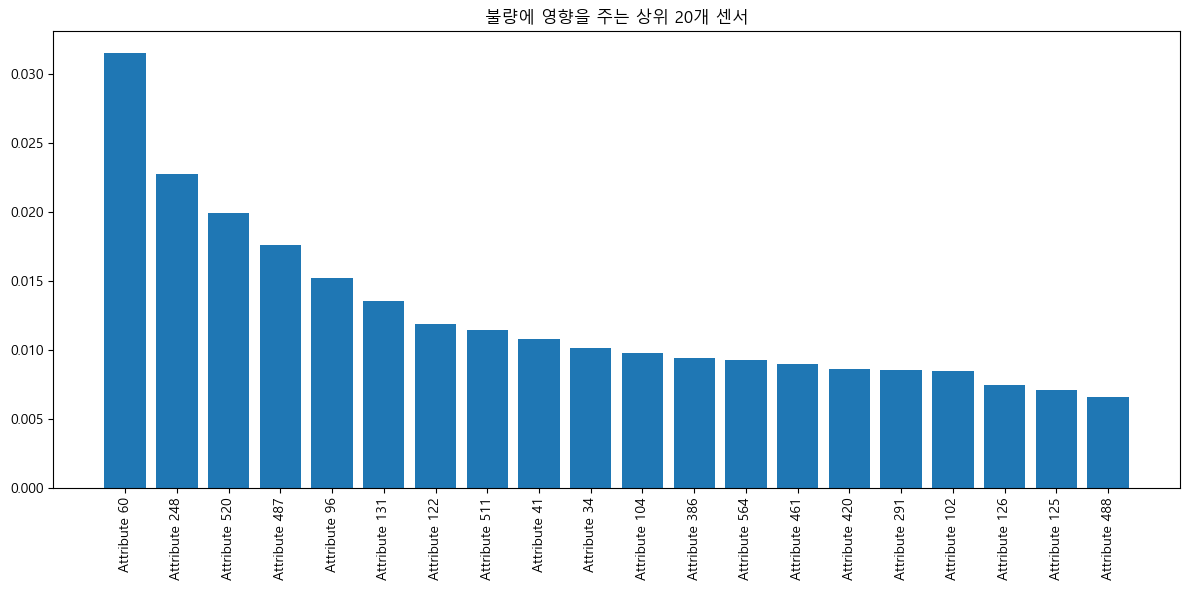

상위 3개 센서: ['Attribute 60', 'Attribute 248', 'Attribute 520']


In [13]:
# ── 셀 13: 피처 중요도 시각화 ─────────────────────────
# 랜덤포레스트가 불량 예측에 중요하게 사용한 센서 상위 20개
# → 어떤 공정 변수가 불량에 가장 큰 영향을 미치는지 파악
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'

importances = model.feature_importances_
feature_names = X.columns
indices = importances.argsort()[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.title('불량에 영향을 주는 상위 20개 센서')
plt.tight_layout()
plt.show()

print("상위 3개 센서:", [feature_names[i] for i in indices[:3]])

In [15]:
# ── 셀 14: 임계값 조정 실험 ──────────────────────────
# predict_proba()[:, 0]: classes_[0]=-1이므로 불량(-1) 확률
# 임계값을 0.3~0.8 사이에서 변화시키며 Recall/Precision 트레이드오프 확인
# 반도체 공정에서 불량 미탐지 비용 > 오탐지 비용이므로 Recall 우선
from sklearn.metrics import recall_score, precision_score, f1_score
y_prob = model.predict_proba(X_test)[:, 0] # 불량(-1) 확률

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = (y_prob >= t).astype(int)
    pred = pd.Series(pred).map({0: 1, 1: -1}) # 1→불량(-1), 0→양품(1)
    r = recall_score(y_test, pred, pos_label=-1)
    p = precision_score(y_test, pred, pos_label=-1, zero_division=0)
    f = f1_score(y_test, pred, pos_label=-1)
    print(f"임계값 {t:.1f} → Recall: {r:.3f}, Precision: {p:.3f}, F1: {f:.3f}")

임계값 0.3 → Recall: 1.000, Precision: 0.924, F1: 0.960
임계값 0.4 → Recall: 1.000, Precision: 0.924, F1: 0.960
임계값 0.5 → Recall: 1.000, Precision: 0.924, F1: 0.960
임계값 0.6 → Recall: 0.986, Precision: 0.926, F1: 0.955
임계값 0.7 → Recall: 0.900, Precision: 0.932, F1: 0.916
임계값 0.8 → Recall: 0.745, Precision: 0.952, F1: 0.836


In [16]:
# ── 셀 15: 최적 임계값 0.5 최종 적용 ─────────────────
# 0.3~0.5 구간에서 Recall 1.0으로 동일
# 같은 성능이면 임계값이 높을수록 오탐지가 줄어들므로 0.5 선택
# classification_report로 클래스별 상세 지표 출력
y_pred_final = (y_prob >= 0.5).astype(int)
y_pred_final = pd.Series(y_pred_final).map({0: 1, 1: -1})
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
# ── 셀 16: 예측 결과 CSV 저장 ──────────────────────
# 테스트셋 센서 데이터에 실제/예측 라벨을 붙여 저장
# → 어떤 샘플을 맞추고 놓쳤는지 사후 분석 가능
from sklearn.metrics import recall_score, precision_score, f1_score

y_prob = model.predict_proba(X_test)[:, 0]
y_pred_adj = (y_prob >= 0.5).astype(int)
y_pred_adj = pd.Series(y_pred_adj).map({0: 1, 1: -1})

result = X_test.copy()
result['실제'] = y_test.values
result['예측'] = y_pred_adj.values
result.to_csv('secom_result.csv', index=False)
print("저장 완료")

저장 완료


In [19]:
# ── 셀 17: 모델 비교 (RandomForest vs LogisticRegression) ──
# 동일 조건(SMOTE + 임계값 0.5)에서 두 모델 성능 비교
# LR은 변수 스케일에 민감하므로 StandardScaler 적용 필수
# fit_transform은 train에만, transform은 test에만 (데이터 누수 방지)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_resampled_scaled, y_resampled)

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 0] # 불량(-1) 확률
lr_pred = (lr_proba >= 0.5).astype(int)
lr_pred = pd.Series(lr_pred).map({0: 1, 1: -1})

rf_proba = model.predict_proba(X_test)[:, 0] # 불량(-1) 확률
rf_pred = (rf_proba >= 0.5).astype(int)
rf_pred = pd.Series(rf_pred).map({0: 1, 1: -1})
# pos_label=-1: 불량 클래스 기준 지표 (프로젝트 목표에 맞게)
comparison = pd.DataFrame({
    '모델': ['RandomForest', 'LogisticRegression'],
    'Precision': [precision_score(y_test, rf_pred, pos_label=-1),
                  precision_score(y_test, lr_pred, pos_label=-1)],
    'Recall':    [recall_score(y_test, rf_pred, pos_label=-1),
                  recall_score(y_test, lr_pred, pos_label=-1)],
    'F1':        [f1_score(y_test, rf_pred, pos_label=-1),
                  f1_score(y_test, lr_pred, pos_label=-1)]
})
print(comparison.to_string(index=False))

                모델  Precision  Recall       F1
      RandomForest   0.923567     1.0 0.960265
LogisticRegression   0.938849     0.9 0.919014


In [20]:
# ── 셀 18: 결측치 제거 기준별 성능 비교 ────────────────
# 결측치 기준을 30/50/70%로 변경하며 남은 컬럼 수와 성능 변화 측정
# → 노이즈 많은 변수 제거가 모델 성능에 미치는 영향 확인
thresholds_missing = [0.3, 0.5, 0.7]
results_missing = []

for thresh in thresholds_missing:
    df_temp = df.dropna(thresh=len(df) * thresh, axis=1)
    df_temp = df_temp.fillna(df_temp.mean(numeric_only=True))
    X_temp = df_temp.drop(columns=['class', 'timestamp'])
    y_temp = df_temp['class']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42
    )
    sm = SMOTE(random_state=42)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr_res, y_tr_res)

    proba = rf.predict_proba(X_te)[:, 0] # 불량(-1) 확률
    pred = (proba >= 0.5).astype(int)
    pred = pd.Series(pred).map({0: 1, 1: -1})

    results_missing.append({
        '결측치 기준': f'{int(thresh * 100)}%',
        '남은 컬럼 수': X_temp.shape[1],
        'Recall':    recall_score(y_te, pred, pos_label=-1),
        'Precision': precision_score(y_te, pred, pos_label=-1),
        'F1':        f1_score(y_te, pred, pos_label=-1)
    })

df_missing = pd.DataFrame(results_missing)
print(df_missing.to_string(index=False))

결측치 기준  남은 컬럼 수   Recall  Precision       F1
   30%      582 0.996552   0.923323 0.958541
   50%      562 1.000000   0.923567 0.960265
   70%      558 1.000000   0.926518 0.961857


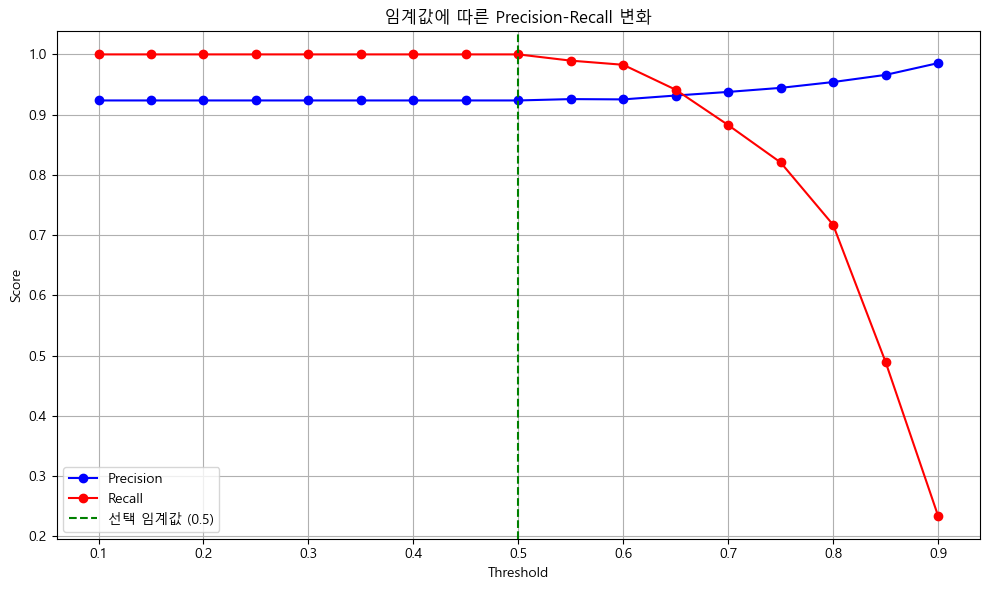

최적 임계값: 0.50
Precision: 0.924, Recall: 1.000, F1: 0.960


In [21]:
# ── 셀 19: 임계값별 Precision-Recall 변화 시각화 ────────
# 임계값 0.1~0.9 구간에서 Precision/Recall 트레이드오프 시각화
# → 0.5 이후 Recall 급락 확인, 선택 임계값 표시
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.95, 0.05)
precisions = []
recalls = []
rf_proba = model.predict_proba(X_test)[:, 0] # 불량(-1) 확률

for t in thresholds:
    pred = (rf_proba >= t).astype(int)
    pred = pd.Series(pred).map({0: 1, 1: -1})
    precisions.append(precision_score(y_test, pred, pos_label=-1, zero_division=0))
    recalls.append(recall_score(y_test, pred, pos_label=-1))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, 'b-o', label='Precision')
plt.plot(thresholds, recalls, 'r-o', label='Recall')
plt.axvline(x=0.5, color='g', linestyle='--', label='선택 임계값 (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('임계값에 따른 Precision-Recall 변화')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Recall 1.0 유지 구간 중 가장 높은 임계값 선택
# → 동일 성능이면 임계값 높을수록 오탐지 감소
f1s = [2*p*r/(p+r) if (p+r) > 0 else 0 for p, r in zip(precisions, recalls)]
best_idx = max(
    [i for i, (r, f) in enumerate(zip(recalls, f1s)) if r >= 1.0],
    key=lambda i: thresholds[i]
)
print(f"최적 임계값: {thresholds[best_idx]:.2f}")
print(f"Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")